<a href="https://colab.research.google.com/github/nakkadharanigoud/COE/blob/main/Team_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
txns=pd.read_csv("/content/ibm.csv")
txns.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#What is the overall attrition rate in the company?
attrition_rate = txns['Attrition'].value_counts()

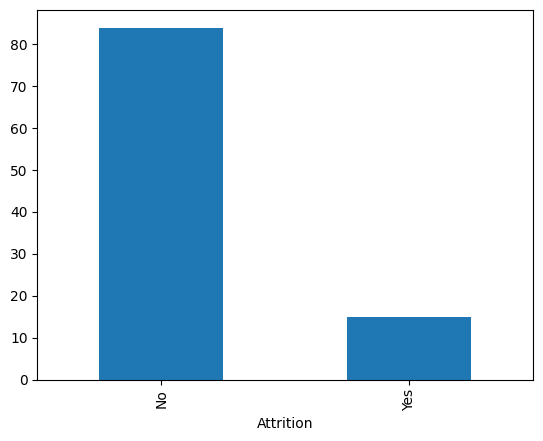

In [ ]:
import matplotlib.pyplot as plt
attrition_rate.plot(kind='bar')
plt.show()

In [ ]:
#What is the overall attrition rate in the company?
attrition_rate = (txns['Attrition'] == 'Yes').mean() * 100
print(attrition_rate)

15.151515151515152


Department
Sales                     18.518519
Research & Development    14.084507
Human Resources                 NaN
Name: count, dtype: float64

Highest Attrition: Sales (18.52%)


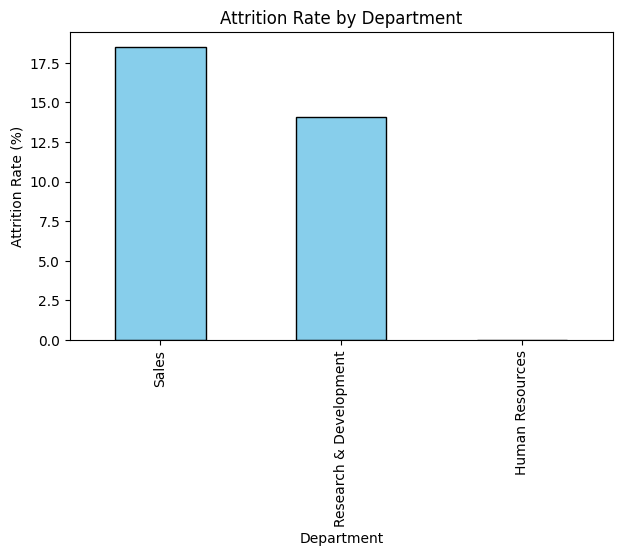

In [ ]:
#Which department has the highest attrition rate?
r = txns[txns.Attrition=='Yes'].Department.value_counts() / txns.Department.value_counts() * 100
print(r.sort_values(ascending=False))
print(f"\nHighest Attrition: {r.idxmax()} ({r.max():.2f}%)")
plt.figure(figsize=(7,4))
r.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [ ]:
#What is the average age of employees who left the company versus those who stayed?
avg_age = txns.groupby('Attrition')['Age'].mean()
print(avg_age)

Attrition
No     37.547619
Yes    36.400000
Name: Age, dtype: float64


In [ ]:
#Does distance from home impact attrition?
b=txns.groupby('Attrition')['DistanceFromHome'].mean()
print(b)

Attrition
No     8.000000
Yes    8.533333
Name: DistanceFromHome, dtype: float64


In [ ]:
#How does attrition vary by gender?
r = txns[txns.Attrition=='Yes'].Gender.value_counts() / txns.Gender.value_counts() * 100
print(r)

Gender
Male      18.750000
Female     8.571429
Name: count, dtype: float64


In [ ]:
#What is the relationship between job satisfaction and attrition?
a=txns.groupby('Attrition')['JobSatisfaction'].mean()
print(a)

Attrition
No     2.750000
Yes    2.866667
Name: JobSatisfaction, dtype: float64


JobRole
Sales Representative         60.000000
Laboratory Technician        20.000000
Research Scientist           20.000000
Research Director            14.285714
Sales Executive              10.000000
Healthcare Representative          NaN
Human Resources                    NaN
Manager                            NaN
Manufacturing Director             NaN
Name: count, dtype: float64


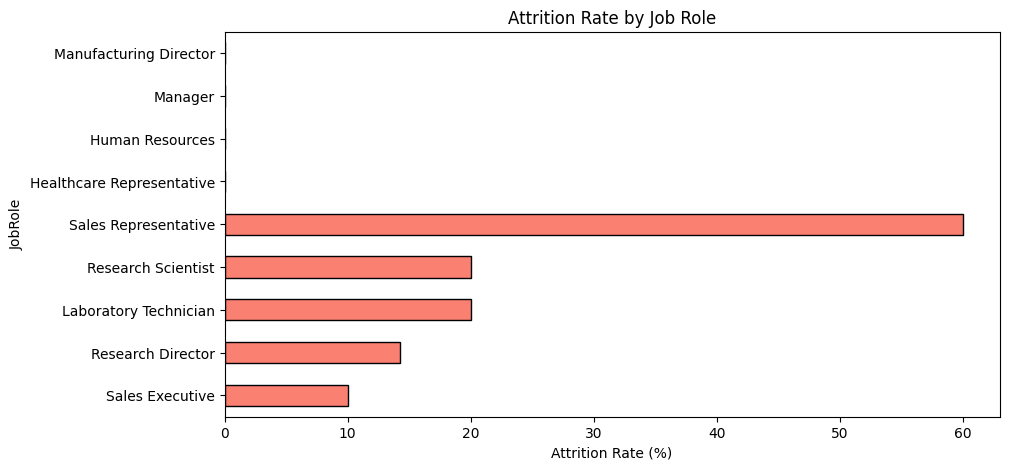

In [ ]:
#Which job roles have the highest attrition rates?
r = txns[txns.Attrition=='Yes'].JobRole.value_counts() / txns.JobRole.value_counts() * 100
print(r.sort_values(ascending=False))
plt.figure(figsize=(10,5))
r.sort_values().plot(kind='barh', color='salmon', edgecolor='black')
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.show()

In [ ]:
#Does education level influence attrition?
r = txns[txns.Attrition=='Yes'].Education.value_counts() / txns.Education.value_counts() * 100
print(r.sort_index())

Education
1    20.000000
2    20.000000
3    18.181818
4     7.142857
5          NaN
Name: count, dtype: float64


In [ ]:
#Are employees with more training less likely to leave?
r = txns.groupby('Attrition')['TrainingTimesLastYear'].mean()
print(r)

Attrition
No     2.797619
Yes    2.533333
Name: TrainingTimesLastYear, dtype: float64


In [ ]:
#Is overtime a major contributor to attrition?
r = txns[txns.Attrition=='Yes'].OverTime.value_counts() / txns.OverTime.value_counts() * 100
print(r)

OverTime
No      9.090909
Yes    27.272727
Name: count, dtype: float64


In [ ]:
 #What is the average monthly income of employees who left vs stayed?
r = txns.groupby('Attrition')['MonthlyIncome'].mean()
print(r)

Attrition
No     6297.988095
Yes    4741.733333
Name: MonthlyIncome, dtype: float64


In [ ]:
#How does attrition vary by marital status?
r = txns[txns.Attrition=='Yes'].MaritalStatus.value_counts() / txns.MaritalStatus.value_counts() * 100
print(r.sort_values(ascending=False))

MaritalStatus
Single      27.027027
Married     12.500000
Divorced          NaN
Name: count, dtype: float64


Attrition
No     11.392857
Yes     9.133333
Name: TotalWorkingYears, dtype: float64


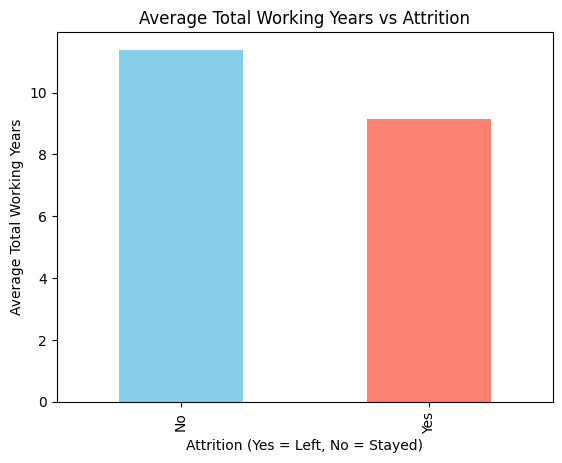

In [ ]:
#What is the relationship between total working years and attrition?
r = txns.groupby('Attrition')['TotalWorkingYears'].mean()
print(r)
import matplotlib.pyplot as plt

r.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Total Working Years vs Attrition')
plt.ylabel('Average Total Working Years')
plt.xlabel('Attrition (Yes = Left, No = Stayed)')
plt.show()

In [ ]:
#Which age group experiences the most attrition?
txns['AgeGroup'] = pd.cut(txns['Age'], bins=[18,25,35,45,55,65], labels=['18-25','26-35','36-45','46-55','56-65'])
r = txns[txns.Attrition=='Yes'].AgeGroup.value_counts()
print(r)

AgeGroup
36-45    6
26-35    5
46-55    3
18-25    1
56-65    0
Name: count, dtype: int64


In [ ]:
#How does environment satisfaction relate to attrition?
r = txns.groupby('Attrition')['EnvironmentSatisfaction'].mean()
print(r)

Attrition
No     2.583333
Yes    2.466667
Name: EnvironmentSatisfaction, dtype: float64


In [ ]:
#What is the distribution of job levels among employees who left?
r = txns[txns.Attrition=='Yes'].JobLevel.value_counts().sort_index()
print(r)

JobLevel
1    10
2     2
3     2
5     1
Name: count, dtype: int64


In [ ]:
#Are employees with higher performance ratings less likely to leave?
r = txns.groupby('Attrition')['PerformanceRating'].mean()
print(r)

Attrition
No     3.226190
Yes    3.133333
Name: PerformanceRating, dtype: float64


BusinessTravel
Travel_Rarely        18.421053
Travel_Frequently     5.882353
Non-Travel                 NaN
Name: count, dtype: float64


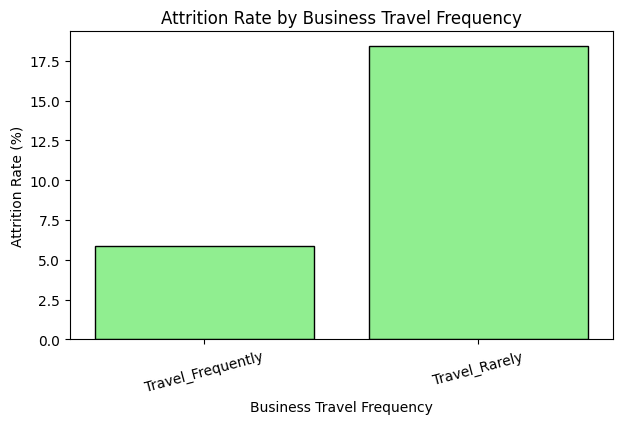

In [ ]:
#How does business travel frequency affect attrition?
r = txns[txns.Attrition=='Yes'].BusinessTravel.value_counts() / txns.BusinessTravel.value_counts() * 100
print(r.sort_values(ascending=False))
plt.figure(figsize=(7,4))
plt.bar(r.index, r.values, color='lightgreen', edgecolor='black')
plt.title('Attrition Rate by Business Travel Frequency')
plt.xlabel('Business Travel Frequency')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.show()

Department
Sales                     6624.370370
Research & Development    5863.070423
Human Resources           5021.000000
Name: MonthlyIncome, dtype: float64


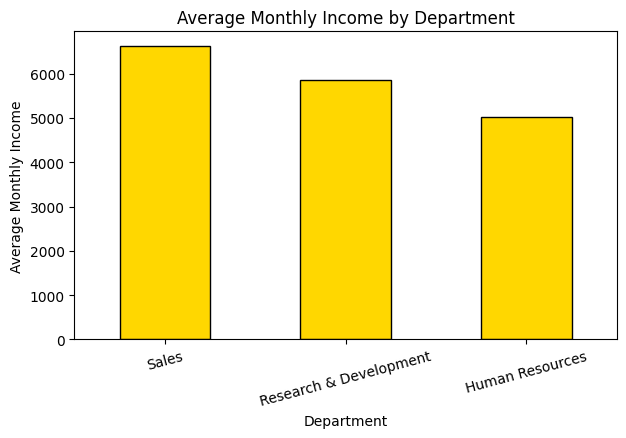

In [ ]:
#Which department pays the highest average monthly income?
r = txns.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending=False)
print(r)
plt.figure(figsize=(7,4))
r.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=15)
plt.show()

In [ ]:
#How does attrition vary by job involvement level?
r = txns[txns.Attrition=='Yes'].JobInvolvement.value_counts() / txns.JobInvolvement.value_counts() * 100
print(r.sort_index())

JobInvolvement
1    50.000000
2    25.925926
3    10.344828
4          NaN
Name: count, dtype: float64


In [ ]:
#21 Do employees with stock options stay longer in the company?
r = txns.groupby('StockOptionLevel')['YearsAtCompany'].mean()
print(r)

StockOptionLevel
0    7.530612
1    5.972222
2    6.000000
3    9.666667
Name: YearsAtCompany, dtype: float64


Attrition
No     15.452381
Yes    14.866667
Name: PercentSalaryHike, dtype: float64


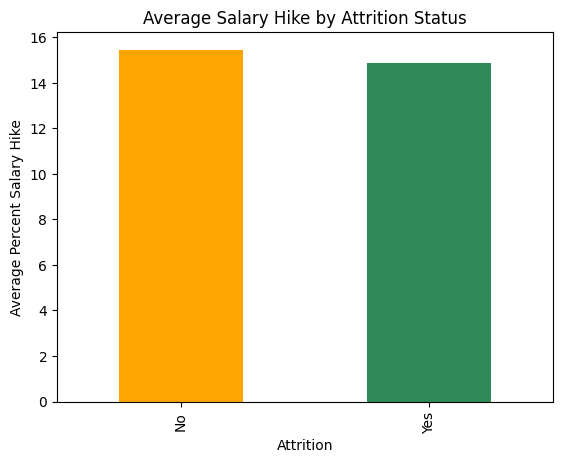

In [ ]:
#22 Is there a relationship between salary hike percentage and attrition?
r = txns.groupby('Attrition')['PercentSalaryHike'].mean()
print(r)
r.plot(kind='bar', color=['orange', 'seagreen'])
plt.title("Average Salary Hike by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Percent Salary Hike")
plt.show()

In [ ]:
#23 How many employees work overtime in each department?
r = txns[txns.OverTime=='Yes'].Department.value_counts()
print(r)

Department
Research & Development    25
Sales                      7
Human Resources            1
Name: count, dtype: int64


In [ ]:
#24 What is the correlation between years at the company and years since last promotion?
r = txns['YearsAtCompany'].corr(txns['YearsSinceLastPromotion'])
print(f"Correlation: {r:.2f}")

Correlation: 0.61


In [ ]:
#25 Do employees with longer tenure tend to have higher satisfaction scores?
r = txns.groupby(pd.cut(txns['YearsAtCompany'], bins=[0,5,10,20,40], labels=['0-5','6-10','11-20','21+']))['JobSatisfaction'].mean()
print(r)

YearsAtCompany
0-5      2.653061
6-10     2.892857
11-20    3.090909
21+      2.857143
Name: JobSatisfaction, dtype: float64


/tmp/ipython-input-3014739408.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r = txns.groupby(pd.cut(txns['YearsAtCompany'], bins=[0,5,10,20,40], labels=['0-5','6-10','11-20','21+']))['JobSatisfaction'].mean()


In [ ]:
#26 How many employees have worked in multiple companies before joining?
r = (txns['NumCompaniesWorked'] > 1).sum()
print(f"Employees with multiple companies before: {r}")

Employees with multiple companies before: 44


WorkLifeBalance
1    33.333333
2    13.793103
3    15.000000
4    14.285714
Name: count, dtype: float64


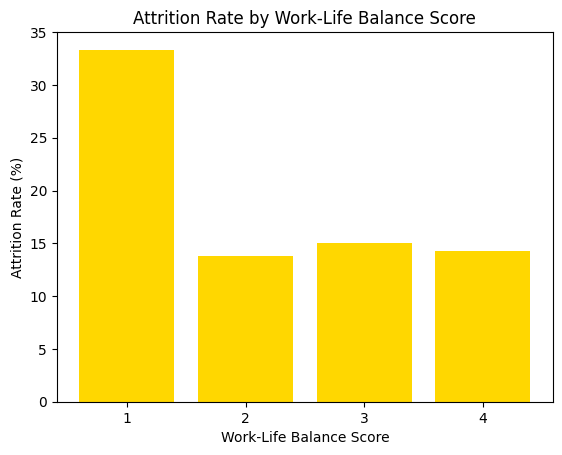

In [ ]:
#27 How does attrition vary based on work-life balance score?
r = txns[txns.Attrition=='Yes'].WorkLifeBalance.value_counts() / txns.WorkLifeBalance.value_counts() * 100
print(r.sort_index())
plt.bar(r.index.astype(str), r.values, color='gold')
plt.title("Attrition Rate by Work-Life Balance Score")
plt.xlabel("Work-Life Balance Score")
plt.ylabel("Attrition Rate (%)")
plt.show()

JobRole
Manager                      17056.000000
Research Director            14885.000000
Healthcare Representative     8782.250000
Sales Executive               6598.600000
Manufacturing Director        6464.444444
Human Resources               5021.000000
Research Scientist            3630.000000
Laboratory Technician         3087.800000
Sales Representative          2502.400000
Name: MonthlyIncome, dtype: float64


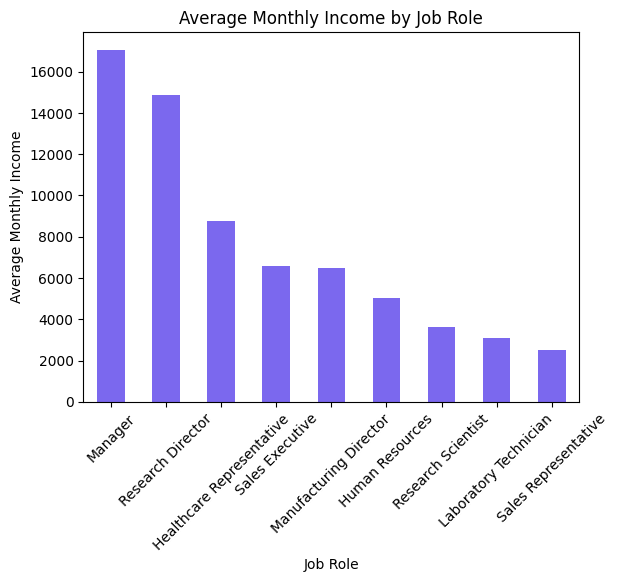

In [ ]:
#28 What is the average monthly income per job role?
r = txns.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print(r)
r.plot(kind='bar', color='mediumslateblue')
plt.title("Average Monthly Income by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

In [ ]:
#29 Which education field has the most employees?
r = txns['EducationField'].value_counts()
print(r)

EducationField
Life Sciences       44
Medical             32
Marketing           10
Other                7
Technical Degree     6
Name: count, dtype: int64


In [ ]:
#30 How does attrition vary across different education fields?
r = txns[txns.Attrition=='Yes'].EducationField.value_counts() / txns.EducationField.value_counts() * 100
print(r.sort_values(ascending=False))

EducationField
Technical Degree    50.000000
Other               14.285714
Life Sciences       13.636364
Medical             12.500000
Marketing           10.000000
Name: count, dtype: float64


In [ ]:
#31 What is the average number of years since last promotion by department?
r = txns.groupby('Department')['YearsSinceLastPromotion'].mean()
print(r)

Department
Human Resources           0.000000
Research & Development    2.352113
Sales                     1.740741
Name: YearsSinceLastPromotion, dtype: float64


In [ ]:
#32 Are employees with more training sessions more satisfied?
r = txns.groupby('TrainingTimesLastYear')['JobSatisfaction'].mean()
print(r)

TrainingTimesLastYear
0    3.200000
1    2.833333
2    2.838710
3    2.675676
4    2.888889
5    2.375000
6    3.000000
Name: JobSatisfaction, dtype: float64


In [ ]:
#33 How does performance rating affect salary hikes?
r = txns.groupby('PerformanceRating')['PercentSalaryHike'].mean()
print(r)

PerformanceRating
3    13.615385
4    21.857143
Name: PercentSalaryHike, dtype: float64


In [ ]:
#34 Do employees with high environment satisfaction also report high job satisfaction?
r = txns[['EnvironmentSatisfaction','JobSatisfaction']].corr().iloc[0,1]
print(f"Correlation: {r:.2f}")

Correlation: 0.14


In [ ]:
#35 What is the gender ratio across different job roles?
r = txns.groupby('JobRole')['Gender'].value_counts(normalize=True) * 100
print(r)

JobRole                    Gender
Healthcare Representative  Male       75.000000
                           Female     25.000000
Human Resources            Male      100.000000
Laboratory Technician      Male       72.000000
                           Female     28.000000
Manager                    Female    100.000000
Manufacturing Director     Male       66.666667
                           Female     33.333333
Research Director          Female     71.428571
                           Male       28.571429
Research Scientist         Male       75.000000
                           Female     25.000000
Sales Executive            Male       60.000000
                           Female     40.000000
Sales Representative       Male       80.000000
                           Female     20.000000
Name: proportion, dtype: float64


In [ ]:
#36 What is the average age per job role?
r = txns.groupby('JobRole')['Age'].mean().sort_values(ascending=False)
print(r)

JobRole
Manager                      51.750000
Human Resources              46.000000
Research Director            42.000000
Sales Executive              40.250000
Healthcare Representative    38.875000
Sales Representative         36.600000
Manufacturing Director       35.222222
Research Scientist           34.550000
Laboratory Technician        33.840000
Name: Age, dtype: float64


In [ ]:
#37 Which business travel category has the highest average monthly income?
r = txns.groupby('BusinessTravel')['MonthlyIncome'].mean().sort_values(ascending=False)
print(r)

BusinessTravel
Travel_Frequently    6571.294118
Travel_Rarely        6019.697368
Non-Travel           5158.000000
Name: MonthlyIncome, dtype: float64


In [ ]:
#38 Do employees with higher job involvement have better performance ratings?
r = txns.groupby('JobInvolvement')['PerformanceRating'].mean()
print(r)

JobInvolvement
1    3.250000
2    3.148148
3    3.258621
4    3.100000
Name: PerformanceRating, dtype: float64


In [ ]:
#39 How many employees are in each job level?
r = txns['JobLevel'].value_counts().sort_index()
print(r)

JobLevel
1    39
2    33
3    19
4     4
5     4
Name: count, dtype: int64


In [ ]:
#40 What is the correlation between monthly income and total working years?
r = txns['MonthlyIncome'].corr(txns['TotalWorkingYears'])
print(f"Correlation: {r:.2f}")

Correlation: 0.72


In [ ]:
#41 Which department has the most employees?
r = txns['Department'].value_counts()
print(r)

Department
Research & Development    71
Sales                     27
Human Resources            1
Name: count, dtype: int64


In [ ]:
#42 What is the distribution of job satisfaction scores?
r = txns['JobSatisfaction'].value_counts().sort_index()
print(r)

JobSatisfaction
1    20
2    15
3    32
4    32
Name: count, dtype: int64


In [ ]:
#43.What is the trend of attrition across different job roles and job levels?
txns['AttritionFlag'] = (txns['Attrition'] == 'Yes').astype(int)
print(txns.pivot_table(index='JobRole', columns='JobLevel', values='AttritionFlag', aggfunc='mean') * 100)


JobLevel                           1           2      3    4     5
JobRole                                                           
Healthcare Representative        NaN    0.000000    0.0  0.0   NaN
Human Resources                  NaN    0.000000    NaN  NaN   NaN
Laboratory Technician      21.052632    0.000000  100.0  NaN   NaN
Manager                          NaN         NaN    NaN  0.0   0.0
Manufacturing Director           NaN    0.000000    0.0  NaN   NaN
Research Director                NaN         NaN    0.0  NaN  50.0
Research Scientist         25.000000    0.000000    0.0  NaN   NaN
Sales Executive                  NaN    7.142857   20.0  0.0   NaN
Sales Representative       50.000000  100.000000    NaN  NaN   NaN


In [ ]:
#44 What is the average work-life balance score across departments?
r = txns.groupby('Department')['WorkLifeBalance'].mean()
print(r)

Department
Human Resources           3.000000
Research & Development    2.760563
Sales                     2.592593
Name: WorkLifeBalance, dtype: float64


In [ ]:
#45 Which age group has the highest number of managers or executives?
txns['AgeGroup'] = pd.cut(txns['Age'], bins=[18,25,35,45,55,65],
                          labels=['18-25','26-35','36-45','46-55','56-65'])
r = txns[txns['JobRole'].isin(['Manager','Executive'])]['AgeGroup'].value_counts()
print(r)

AgeGroup
46-55    4
18-25    0
26-35    0
36-45    0
56-65    0
Name: count, dtype: int64


In [ ]:
#46 Are older employees more satisfied with their work environment?
r = txns.groupby(pd.cut(txns['Age'], bins=[18,25,35,45,55,65],
                        labels=['18-25','26-35','36-45','46-55','56-65']))['EnvironmentSatisfaction'].mean()
print(r)

Age
18-25    2.333333
26-35    2.608696
36-45    2.769231
46-55    2.187500
56-65    2.600000
Name: EnvironmentSatisfaction, dtype: float64


/tmp/ipython-input-79706831.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r = txns.groupby(pd.cut(txns['Age'], bins=[18,25,35,45,55,65],


In [ ]:
#47 What is the most common business travel frequency among top performers?
top_perf = txns[txns['PerformanceRating'] == txns['PerformanceRating'].max()]
r = top_perf['BusinessTravel'].value_counts()
print(r)

BusinessTravel
Travel_Rarely        13
Travel_Frequently     7
Non-Travel            1
Name: count, dtype: int64


In [ ]:
#48 How does training frequency affect job satisfaction?
r = txns.groupby('TrainingTimesLastYear')['JobSatisfaction'].mean()
print(r)

TrainingTimesLastYear
0    3.200000
1    2.833333
2    2.838710
3    2.675676
4    2.888889
5    2.375000
6    3.000000
Name: JobSatisfaction, dtype: float64


In [ ]:
#49.Which combination of factors (age, job role, income) is most linked to attrition?
r = txns[txns.Attrition=='Yes'].groupby(['Age','JobRole','MonthlyIncome']).size()
print(r.sort_values(ascending=False).head(10))


Age  JobRole                MonthlyIncome
24   Research Scientist     2293             1
26   Laboratory Technician  2293             1
28   Laboratory Technician  2028             1
                            3441             1
32   Research Scientist     3919             1
34   Research Scientist     2960             1
36   Research Scientist     3388             1
     Sales Representative   3407             1
37   Laboratory Technician  2090             1
39   Sales Representative   2086             1
dtype: int64


In [ ]:
#50.Can we predict potential attrition based on salary, satisfaction, and working years (for ML modeling)?
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x = txns[['MonthlyIncome','JobSatisfaction','TotalWorkingYears']]
y = txns['Attrition'].map({'Yes':1,'No':0})

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(x_train, y_train)
pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.85
